# Weighting with MAIC / entropy balancing

Every matcher elsewhere in `pybalance` (genetic, LP, propensity) works by **selecting a subset**
of the pool. `pybalance.weighting` instead **reweights every pool patient**, so nothing is
dropped -- some patients just count for more (or less) than others. This is the standard approach
for **Matching-Adjusted Indirect Comparison (MAIC)** (Signorovitch et al., 2010): reweighting a
trial's patient-level data ("IPD") so its weighted covariate moments match a comparator's
**published, aggregate-only** statistics (e.g. a Table 1 of means and proportions), enabling an
indirect treatment comparison when the comparator's own patient-level data isn't available.

- `MAICWeighter` -- the classic MAIC formulation: matches the disclosed **first moments** (means,
  category rates, and the rate above a disclosed median/quantile).
- `EntropyBalanceWeighter` -- the general form MAIC is a special case of: optionally *also*
  balances the **variance** of numeric features whose target discloses a mean and a std.

The notebook mirrors the aggregate-matching demo: the same three use cases, each disclosing a bit
more or something different about the target:
1. **means only** (plus a categoric proportion);
2. **means and stds**, which adds a variance constraint;
3. **medians and other quantiles instead of means**, plus a soft **max**.

As there, only disclosed statistics are constrained. Features the target says nothing about (here
`height` and `country`) are left free, but we keep them in the `MatchingData` so we can still see
how reweighting changes them. A last section covers what happens when the target lies outside the
pool's support.

Both weighters also work with a patient-level target, and both return an ordinary `MatchingData`,
just with every pool row now carrying a fitted weight column.

In [1]:
import logging

import matplotlib.pyplot as plt
import pandas as pd

from pybalance.sim import (
    generate_toy_dataset,
    get_demo_aggregate_target_path,
    load_demo_aggregate_target,
)
from pybalance.utils import AggregateTarget, MatchingData, MatchingHeaders
from pybalance.visualization import plot_aggregate_target_match
from pybalance.weighting import (
    EntropyBalanceWeighter,
    MAICWeighter,
    weighted_balance_table,
)

%matplotlib inline

# show convergence / effective-sample-size diagnostics logged during fit()
logging.basicConfig(level=logging.INFO, format="%(message)s", force=True)

## A patient-level (synthetic) pool

MAIC needs patient-level data only for the **pool** (our "IPD"). `generate_toy_dataset` returns an
entirely simulated one (no real patients); with `n_target=0` it generates no target patients at
all, since the target will come from summary statistics instead -- as in the aggregate-matching
demo.

In [2]:
m = generate_toy_dataset(n_pool=1000, n_target=0, seed=7)
pool = m.get_population("pool").drop(columns=[m.population_col])
pool.head()

,age,height,weight,gender,haircolor,country,binary_0,binary_1,binary_2,binary_3,patient_id
0,69.436489,155.189260,79.144533,0.0,1,4,0,0,1,1,0
1,28.771438,175.270602,97.734561,1.0,0,5,0,0,1,1,1
2,62.640154,136.648640,85.170055,0.0,1,2,0,0,0,1,2
3,68.907932,189.959952,90.705549,0.0,1,3,0,0,1,1,3
4,49.571169,133.787109,76.708193,1.0,2,3,0,0,0,1,4


## Specifying means only

An `AggregateTarget` is the target's sample size `n` plus whatever summary statistics are disclosed
-- a published Table 1:

- `numeric`: per feature, e.g. `{"mean": ...}`;
- `categoric`: per feature, `{level: rate}` -- the proportion of each category.

Here the target discloses the mean `age` and `weight` and the proportion of each `gender`.

In [3]:
my_target = AggregateTarget(
    n=250,
    numeric={
        "age": {"mean": 64.0},
        "weight": {"mean": 80.0},
    },
    categoric={"gender": {0: 0.35, 1: 0.65}},
)
my_target

feature,type,stat,value
age,numeric,mean,64.00
weight,numeric,mean,80.00
gender,categoric,0,0.35
gender,categoric,1,0.65


To reweight, wrap the pool and the target in a `MatchingData` and hand it to `MAICWeighter`.
`match()` fits (if needed) and returns a `MatchingData` with every pool patient retained, plus a
new `sample_weight` column (the default `weight_col`; note it's *not* called `"weight"`, since
`weight` here is itself a genuine covariate -- `MAICWeighter` refuses to silently clobber a
matching feature and raises if `weight_col` collides with one).

The `headers` say which pool columns we want to look at. They may include features the target does
not disclose -- here `height` and `country`. Those are left unconstrained by the weighter, but
reported in the results.

`weighted_balance_table()` compares each balanced feature's target moment to both the
**unweighted** and **weighted** pool moment -- the "weighted" column should land right on target.

In [4]:
headers = MatchingHeaders(numeric=["age", "weight", "height"], categoric=["gender", "country"])

matching_data = MatchingData(pool=pool, target=my_target, headers=headers)
weighter = MAICWeighter(matching_data, verbose=True)
matched = weighter.match()

weighted_balance_table(weighter)

MAICWeighter converged in 6 iterations. Effective sample size: 377.7 / 1000 pool patients.


,feature,moment,target,unweighted_pool,weighted_pool
0,gender_1.0,mean,0.65,0.517000,0.650000
1,country_1,mean,NaN,0.108000,0.095055
2,country_2,mean,NaN,0.224000,0.219909
3,country_3,mean,NaN,0.274000,0.301231
4,country_4,mean,NaN,0.284000,0.303890
5,country_5,mean,NaN,0.110000,0.079916
6,age,mean,64.00,55.520107,64.000000
7,weight,mean,80.00,88.016510,80.000000
8,height,mean,NaN,160.308334,156.103230


`age`, `weight` and `gender` land right on their targets in the weighted column. `height` and the
`country` levels have no target (`NaN`) -- nothing constrains them -- but we can still see how they
moved as a side effect of reweighting.

The **effective sample size (ESS)**, $\left(\sum_i w_i\right)^2 / \sum_i w_i^2$, summarizes how
"spread out" the weights are: it equals the pool size when all weights are equal, and shrinks
towards 1 as more and more of the total weight concentrates on fewer patients. A large drop from
the raw pool size is the standard MAIC red flag that the reweighting is relying heavily on a
small, possibly unrepresentative, slice of the pool -- worth showing alongside any MAIC result.

In [5]:
print(f"Effective sample size: {weighter.effective_sample_size():.1f} / {len(pool)} pool patients")
print(f"Converged: {weighter.diagnostics['converged']}")
print(f"Weight summary (sums to target n={my_target.n} by default):")
matched.get_population(matched.pool_name)["sample_weight"].describe()

Effective sample size: 377.7 / 1000 pool patients
Converged: True
Weight summary (sums to target n=250 by default):


count    1000.000000
mean        0.250000
std         0.321042
min         0.002645
25%         0.060622
50%         0.144954
75%         0.304432
max         3.993364
Name: sample_weight, dtype: float64

Since the target here is an `AggregateTarget`, it has no patient-level rows for
`plot_numeric_features`/`plot_categoric_features` to draw a distribution for -- as of this version,
passing one logs a warning and shows nothing useful. Use `plot_aggregate_target_match()` instead:
one panel per disclosed constraint, showing where the pool lands before vs. after weighting
relative to the disclosed value, in its own units. Pass `weights=` to compare the *weighted* pool.

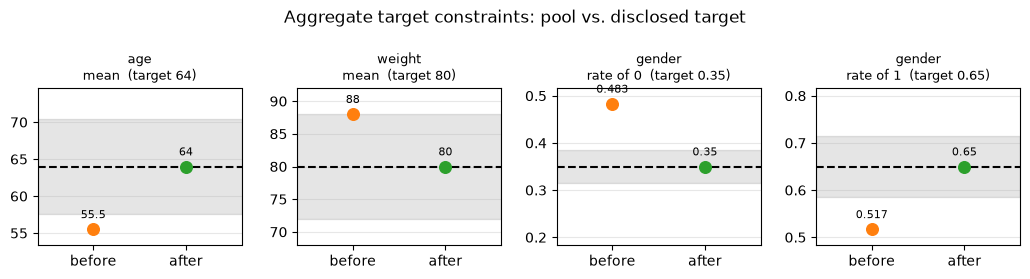

In [6]:
fig = plot_aggregate_target_match(matching_data, matched, weights=weighter.weight_col)

## Specifying means and standard deviations

A Table 1 sometimes discloses a standard deviation alongside a mean. `EntropyBalanceWeighter` is the
general form `MAICWeighter` is a (mean-only) special case of: pass `match_variance=True` to
*additionally* constrain the weighted variance of every numeric feature whose target discloses a
`std` (categoric features are never variance-constrained -- their variance is already fixed by
their matched rate). The variance is taken around the disclosed mean, so a std needs its mean.

Typing targets out by hand gets long, so `pybalance.sim` ships ready-made ones, the same as in the
aggregate-matching demo: `load_demo_aggregate_target(use_case)` returns the packaged
`AggregateTarget` (and `generate_aggregate_target(use_case)` derives the same thing from a toy
dataset -- or from your own patient-level `MatchingData`).

| `use_case` | disclosed statistics |
|---|---|
| `means` | `age` and `weight` means, `gender` rates |
| `means_std` | `age` and `weight` means and stds, `gender` rates |
| `quantiles` | `age` quartiles and `weight` median (instead of means), `gender` rates |

Load `means_std` and reweight. Displaying the target shows exactly what it discloses; the table now
has a `variance` row for `age` and `weight` next to their means.

In [7]:
target_b = load_demo_aggregate_target("means_std")
display(target_b)

weighter_b = EntropyBalanceWeighter(
    MatchingData(pool=pool, target=target_b, headers=headers), match_variance=True, verbose=True
)
weighter_b.match()

weighted_balance_table(weighter_b)

feature,type,stat,value
age,numeric,mean,50.795973
age,numeric,std,15.019030
weight,numeric,mean,82.079040
weight,numeric,std,18.721164
gender,categoric,0.0,0.550000
gender,categoric,1.0,0.450000


EntropyBalanceWeighter converged in 6 iterations. Effective sample size: 639.1 / 1000 pool patients.


,feature,moment,target,unweighted_pool,weighted_pool
0,gender_1.0,mean,0.450000,0.517000,0.450000
1,country_1,mean,NaN,0.108000,0.108157
2,country_2,mean,NaN,0.224000,0.216864
3,country_3,mean,NaN,0.274000,0.258550
4,country_4,mean,NaN,0.284000,0.311152
5,country_5,mean,NaN,0.110000,0.105278
6,age,mean,50.795975,55.520107,50.795975
7,age,variance,225.571251,171.687210,225.571241
8,weight,mean,82.079041,88.016510,82.079041
9,weight,variance,350.482008,273.742310,350.481995


## Specifying medians and quantiles instead of means

Published Table 1s often report a **median** ("age, median: 41") or other **quantiles** ("age, IQR:
35-52") instead of a mean for a skewed covariate. A **quantile** `(q, value)` means
P(raw <= value) = q, and a median is the single quantile 0.5: `{"age": {"median": 41.0}}` is
exactly `{"age": {"quantile": [(0.5, 41.0)]}}`. The disclosed value is the cutpoint: the weighter
dichotomizes the raw column there and matches the resulting rate, so you never compute the 0/1
column yourself. Here `age` discloses its quartiles and `weight` only a median.

A target like this is easiest to keep in a file, and that is what `load_demo_aggregate_target` has
been reading all along. Here is the packaged `quantiles` file:

In [8]:
path = get_demo_aggregate_target_path("quantiles")
print(path, end="\n\n")
print(open(path).read())

/Users/gmema/src/matching-fork/venv/lib/python3.12/site-packages/pybalance/sim/data/aggregate_target_quantiles.csv

feature,statistic,parameter,value
,n,,100
age,quantile,0.25,41.37572755384545
age,median,,53.71747134991201
age,quantile,0.75,63.69799477706703
weight,median,,82.66384310636546
gender,rate,0.0,0.55
gender,rate,1.0,0.45



The file has one row per disclosed statistic, in four columns (`feature`, `statistic`, `parameter`,
`value`): `n`, then `mean` / `std` / `median` / `min` / `max` rows for numeric features, `quantile`
rows (with the proportion `q` in `parameter`) and `rate` rows (with the category level in
`parameter`) for categoric ones. `AggregateTarget.from_csv(path)` reads it and `to_csv()` writes
it, so a published Table 1 can be transcribed into a spreadsheet and loaded directly.

Now load it and reweight. `MAICWeighter` matches the **rate above each disclosed quantile** -- the
`age_q0.25_1.0`, `age_q0.5_1.0`, ... rows below are the indicators "age is above its disclosed
quartile / median", whose target rate is `1 - q`. There is no mean for `age` or `weight`, so the
table has no raw-feature rows to compare for them.

In [9]:
target_c = AggregateTarget.from_csv(path)
display(target_c)

weighter_c = MAICWeighter(MatchingData(pool=pool, target=target_c, headers=headers), verbose=True)
weighter_c.match()

weighted_balance_table(weighter_c)

feature,type,stat,value
age,numeric,quantile_0.25,41.375728
age,numeric,quantile_0.5,53.717471
age,numeric,quantile_0.75,63.697995
weight,numeric,quantile_0.5,82.663843
gender,categoric,0.0,0.550000
gender,categoric,1.0,0.450000


MAICWeighter converged in 6 iterations. Effective sample size: 830.9 / 1000 pool patients.


,feature,moment,target,unweighted_pool,weighted_pool
0,gender_1.0,mean,0.45,0.517000,0.450000
1,country_1,mean,NaN,0.108000,0.110618
2,country_2,mean,NaN,0.224000,0.223352
3,country_3,mean,NaN,0.274000,0.265532
4,country_4,mean,NaN,0.284000,0.290569
5,country_5,mean,NaN,0.110000,0.109929
6,age_q0.25_1.0,mean,0.75,0.836000,0.750000
7,age_q0.5_1.0,mean,0.50,0.600000,0.500000
8,age_q0.75_1.0,mean,0.25,0.339000,0.250000
9,weight_q0.5_1.0,mean,0.50,0.622000,0.500000


### A soft maximum

Trials also report ranges ("weight, max: 100"). `min` and `max` are simply the 0th and 100th
quantile, so they can be added to any numeric feature: `{"weight": {"median": 82.7, "max": 100.0}}`,
or a `min`/`max` row in the CSV. As in the matching demo they are **soft**. For a weighter there is
a concrete reason: weights are strictly positive, so *exactly* zero weight on patients above a max
cannot be reached. Instead the weight above the max is penalized (`limit_penalty`, 0.01 by default;
larger values enforce it more tightly) and shrinks to a small remainder, while the quartiles and the
median are still matched exactly.

Here we take use case 3's target and add a ceiling on `weight`:

In [10]:
numeric = {feature: dict(stats) for feature, stats in target_c.numeric.items()}
numeric["weight"]["max"] = 100.0  # soft ceiling: no patient heavier than 100kg

target_d = AggregateTarget(n=target_c.n, numeric=numeric, categoric=target_c.categoric)
display(target_d)

weighter_d = MAICWeighter(MatchingData(pool=pool, target=target_d, headers=headers), verbose=True)
weighter_d.match()

above = (pool["weight"] > 100).to_numpy()
share = weighter_d.weights[above].sum() / weighter_d.weights.sum()
print(f"Share of the pool above 100kg: {above.mean():.1%} unweighted, {share:.1%} weighted")

weighted_balance_table(weighter_d)

feature,type,stat,value
age,numeric,quantile_0.25,41.375728
age,numeric,quantile_0.5,53.717471
age,numeric,quantile_0.75,63.697995
weight,numeric,quantile_0.5,82.663843
weight,numeric,max,100.000000
gender,categoric,0.0,0.550000
gender,categoric,1.0,0.450000


Detected constant feature(s) in target population: weight_q1.0_0.0,weight_q1.0_1.0.
MAICWeighter converged in 7 iterations. Effective sample size: 653.8 / 1000 pool patients.


Share of the pool above 100kg: 27.1% unweighted, 0.8% weighted


,feature,moment,target,unweighted_pool,weighted_pool
0,gender_1.0,mean,0.45,0.517000,0.450000
1,country_1,mean,NaN,0.108000,0.117517
2,country_2,mean,NaN,0.224000,0.221034
3,country_3,mean,NaN,0.274000,0.270855
4,country_4,mean,NaN,0.284000,0.278525
5,country_5,mean,NaN,0.110000,0.112069
6,age_q0.25_1.0,mean,0.75,0.836000,0.750000
7,age_q0.5_1.0,mean,0.50,0.600000,0.500000
8,age_q0.75_1.0,mean,0.25,0.339000,0.250000
9,weight_q0.5_1.0,mean,0.50,0.622000,0.500000


`plot_aggregate_target_match` -- the per-constraint plot from the matching demo -- takes the weights
too: pass the name of the weight column and the "after" dot is the *weighted* pool, compared with the
unweighted one before. Each panel is one disclosed constraint in its own units (e.g. the 25th, 50th
and 75th percentile of `age`). A disclosed max is plotted as the weighted fraction of patients at or
below it, `P(x <= 100)`, since weights stay positive and the maximum *value* never moves: it rises
from 73% to about 99%, but not all the way to the dashed line at 1.

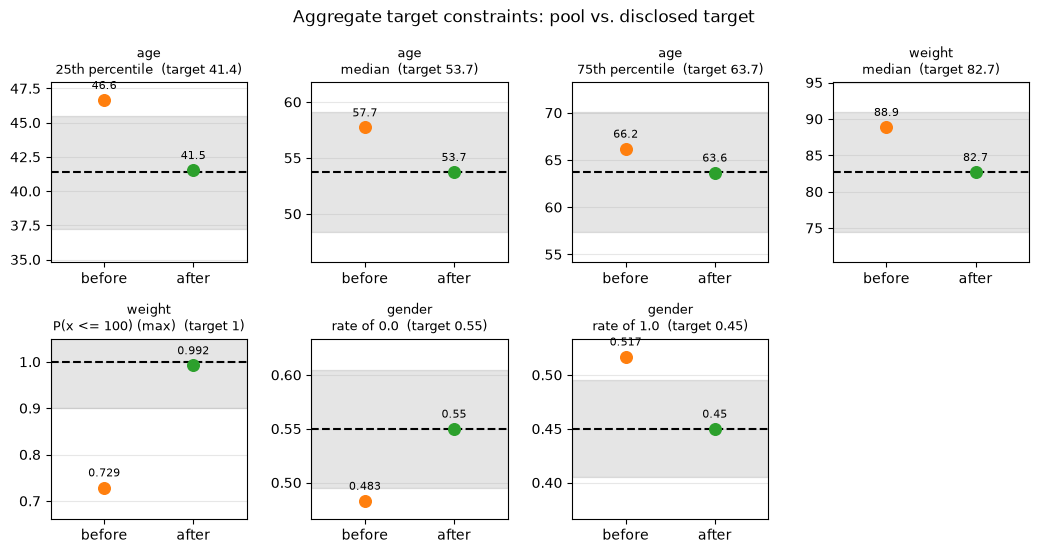

In [11]:
fig = plot_aggregate_target_match(weighter_d.matching_data, weighter_d.match(), weights="sample_weight")

## When the target lies outside the pool's support

MAIC/entropy balancing needs the target to lie within the pool's covariate support -- there must
be *some* valid (possibly very uneven) weighting of the pool that reproduces the target's moments.
Unlike subset-selection matching (which always terminates, just possibly with poor balance),
reweighting can fail outright when this "positivity" assumption breaks down.

The toy pool is deliberately built with **zero** `country=0` patients, while the target has a
nonzero `country=0` rate. Since every pool patient's `country` is one of `{1, ..., 5}`, *any*
reweighting of the pool necessarily puts 100% of its mass on those five categories -- it's
mathematically impossible to also match the target's five corresponding rates, which sum to less
than 100% (the rest being the unreachable `country=0`). We use the actual patient-level target here
(rather than an `AggregateTarget`) to make this concrete: an `AggregateTarget` that discloses a
rate for a category the pool doesn't contain at all silently drops that category from the
constraint set (it has no matching one-hot column to constrain), which would mask the very
infeasibility we want to demonstrate.

In [12]:
hard_m = generate_toy_dataset(n_pool=1000, n_target=100, seed=7)
hard_pool = hard_m.get_population("pool").drop(columns=[hard_m.population_col])
hard_target_pl = hard_m.get_population("target").drop(columns=[hard_m.population_col])
hard_headers = MatchingHeaders(numeric=["age", "weight", "height"], categoric=["gender", "country"])

print("country rate in pool:  ", hard_pool["country"].value_counts(normalize=True).sort_index().to_dict())
print("country rate in target:", hard_target_pl["country"].value_counts(normalize=True).sort_index().to_dict())

hard_matching_data = MatchingData(pool=hard_pool, target=hard_target_pl, headers=hard_headers)

hard_weighter = MAICWeighter(hard_matching_data, verbose=True)
hard_weighter.match()

weighted_balance_table(hard_weighter)

MAICWeighter did not converge within 200 iterations (max constraint violation = 0.296). Weights may not exactly balance the requested moments; consider increasing max_iter/ridge, or check for unmatchable (e.g. near-extreme or non-overlapping) covariates.


country rate in pool:   {1: 0.108, 2: 0.224, 3: 0.274, 4: 0.284, 5: 0.11}
country rate in target: {0: 0.09, 1: 0.25, 2: 0.2, 3: 0.11, 4: 0.2, 5: 0.15}


,feature,moment,target,unweighted_pool,weighted_pool
0,gender_1.0,mean,0.450000,0.517000,0.464052
1,country_1,mean,0.250000,0.108000,0.340190
2,country_2,mean,0.200000,0.224000,0.080990
3,country_3,mean,0.110000,0.274000,0.143957
4,country_4,mean,0.200000,0.284000,0.254031
5,country_5,mean,0.150000,0.110000,0.180831
6,age,mean,50.795975,55.520107,51.570918
7,weight,mean,82.079033,88.016510,81.907367
8,height,mean,153.795044,160.308334,154.426966


As expected, the fit reports `converged: False`. Because a valid reweighting of the pool can only
ever distribute 100% of its mass across `country in {1, ..., 5}`, it's mathematically impossible
to simultaneously hit the target's rates for those five categories, which sum to only 91% (the
rest being the unreachable `country=0`) -- there's no weighting that can reconcile the two.
Notice how the optimizer, unable to satisfy the `country` constraints, ends up trading away
balance on *every other* feature too (`gender`, `age`, `weight`, `height` are all now visibly off
target) while it searches for a best-effort compromise, and the effective sample size drops
sharply. This is exactly the honest, "don't silently produce a wrong answer" behavior we want. If
you hit this in practice: check for categories/ranges the target has that the pool structurally
lacks, consider dropping the offending feature, or fall back to subset-selection matching (which
can't invent missing categories either, but degrades more gracefully -- see the aggregate-matching
demo).

In [13]:
print(f"Converged: {hard_weighter.diagnostics['converged']}")
print(f"Max constraint violation: {hard_weighter.diagnostics['max_constraint_violation']:.3f}")
print(f"Effective sample size: {hard_weighter.effective_sample_size():.1f} / {len(hard_pool)} pool patients")

Converged: False
Max constraint violation: 0.296
Effective sample size: 443.4 / 1000 pool patients


## Takeaways

- Weighting keeps **every** pool patient, unlike the subset-selection matchers elsewhere in
  `pybalance` -- some patients just count for more or less. `MAICWeighter` is the classic
  mean-only MAIC formulation; `EntropyBalanceWeighter(match_variance=True)` generalizes it to also
  balance disclosed variances.
- Against an `AggregateTarget`, every disclosed statistic is its own constraint and nothing else is
  constrained: a numeric **mean**, each categoric **rate**, and the rate above each disclosed
  **median/quantile** (the feature is dichotomized at the disclosed value). Features and categoric
  levels the target doesn't disclose are left free, and `weighted_balance_table` still reports them
  (with no target) so you can see how reweighting moved them.
- Balancing a **std** needs the mean as well, since the variance is taken around it. A std without a
  mean isn't a moment constraint reweighting can solve (use the subset-selection matchers).
- **`min` and `max`** are soft here too: exactly zero weight above a max is out of reach for positive
  weights, so the weight above it is only penalized (`limit_penalty`) and shrinks, rather than
  vanishing.
- Both weighters also work with a patient-level target.
- Always check `effective_sample_size()` and `.diagnostics["converged"]` alongside any fitted
  weights -- a low ESS or non-convergence is the signal that the reweighting is stretching thin (or
  failing outright) to reach the target, most often because of a genuine covariate-support mismatch
  between pool and target.